# HVM Latent Sweep Results
Loads all `checkpoints/hvm/transformer/vae_latent_flat/*/best.pt` and compares performance across:
- `d_model` (64 / 128)
- `n_layers` (1 / 2 / 4)
- Learning rate (1e-3 / 3e-4)
- Weight decay (1e-2 / 1e-1)

All runs use category conditioning. Target: full VAE latent `(16, 34, 34)` normalized per channel.  
Primary metric: **val cosine similarity**. MSE is in normalized space (target std ≈ 1 per channel).

In [1]:
import sys
from pathlib import Path

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR

CKPT_ROOT = CHECKPOINT_DIR / 'hvm' / 'transformer' / 'vae_latent_flat'
TARGET_POOL_HW = 34  # full HVM VAE resolution — change to 8 to view pooled-latent runs

rows = []
for pt in tqdm(sorted(CKPT_ROOT.rglob('best.pt'))):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception as e:
        print(f'skip {pt}: {e}')
        continue
    if 'lat_mean' not in ckpt:  # skip legacy runs
        continue
    args = ckpt.get('args', {})
    if args.get('pool_hw') != TARGET_POOL_HW:
        continue
    if 'metrics' not in ckpt:
        continue
    m = ckpt['metrics']
    tm = ckpt.get('test_metrics', {})
    rows.append({
        'path':         str(pt.parent.name),
        'd_model':      args.get('d_model'),
        'n_layers':     args.get('n_layers'),
        'lr':           args.get('lr'),
        'weight_decay': args.get('weight_decay'),
        'pool_hw':      args.get('pool_hw'),
        'epoch':        ckpt.get('epoch'),
        'train_mse':    m.get('train_mse'),
        'val_mse':      m.get('val_mse'),
        'val_cos_sim':  m.get('val_cos_sim'),
        'test_mse':     tm.get('test_mse'),
        'test_cos_sim': tm.get('test_cos_sim'),
    })

df = pd.DataFrame(rows)
print(f'{len(df)} runs loaded (pool_hw={TARGET_POOL_HW})')
df.head()

  0%|          | 0/56 [00:00<?, ?it/s]

24 runs loaded (pool_hw=34)


,path,d_model,n_layers,lr,weight_decay,pool_hw,epoch,train_mse,val_mse,val_cos_sim,test_mse,test_cos_sim
0,d128_nh4_nl1_hw34_do0.1_lr0.0003_wd0.01_bs64_cat,128,1,0.0003,0.01,34,70,0.539019,0.691543,0.540977,0.674422,0.526106
1,d128_nh4_nl1_hw34_do0.1_lr0.0003_wd0.1_bs64_cat,128,1,0.0003,0.10,34,70,0.538953,0.691172,0.541322,0.674054,0.526406
2,d128_nh4_nl1_hw34_do0.1_lr0.001_wd0.01_bs64_cat,128,1,0.0010,0.01,34,28,0.546709,0.690129,0.544102,0.675395,0.524801
3,d128_nh4_nl1_hw34_do0.1_lr0.001_wd0.1_bs64_cat,128,1,0.0010,0.10,34,28,0.546965,0.690291,0.544240,0.676015,0.524459
4,d128_nh4_nl2_hw34_do0.1_lr0.0003_wd0.01_bs64_cat,128,2,0.0003,0.01,34,73,0.530092,0.697664,0.538510,0.683453,0.522778


## Best run per hyperparameter group

In [2]:
cols = ['d_model', 'n_layers', 'lr', 'weight_decay',
        'epoch', 'train_mse', 'val_mse', 'val_cos_sim', 'test_mse', 'test_cos_sim']
available = [c for c in cols if c in df.columns]

summary = (
    df.sort_values('val_cos_sim', ascending=False)
      .groupby(['d_model', 'n_layers'], sort=False)
      .first()
      .reset_index()
)[available]
display(summary)

,d_model,n_layers,lr,weight_decay,epoch,train_mse,val_mse,val_cos_sim,test_mse,test_cos_sim
0,128,2,0.001,0.1,32,0.532195,0.687861,0.545001,0.675766,0.527201
1,128,1,0.001,0.1,28,0.546965,0.690291,0.544240,0.676015,0.524459
2,64,2,0.001,0.1,55,0.535571,0.690150,0.543887,0.671979,0.528813
3,64,1,0.001,0.1,59,0.521376,0.690780,0.543149,0.675410,0.525237
4,64,4,0.001,0.1,62,0.540632,0.692830,0.541251,0.680944,0.523805
5,128,4,0.001,0.1,32,0.547863,0.693478,0.540835,0.683049,0.520872


## Top-10 runs overall

In [3]:
top_cols = [c for c in [
    'd_model', 'n_layers', 'lr', 'weight_decay',
    'epoch', 'train_mse', 'val_cos_sim', 'val_mse', 'test_cos_sim', 'test_mse', 'path'
] if c in df.columns]
display(df.sort_values('val_cos_sim', ascending=False)[top_cols].head(10).reset_index(drop=True))

,d_model,n_layers,lr,weight_decay,epoch,train_mse,val_cos_sim,val_mse,test_cos_sim,test_mse,path
0,128,2,0.0010,0.10,32,0.532195,0.545001,0.687861,0.527201,0.675766,d128_nh4_nl2_hw34_do0.1_lr0.001_wd0.1_bs64_cat
1,128,2,0.0010,0.01,32,0.532310,0.544792,0.688024,0.526752,0.676293,d128_nh4_nl2_hw34_do0.1_lr0.001_wd0.01_bs64_cat
2,128,1,0.0010,0.10,28,0.546965,0.544240,0.690291,0.524459,0.676015,d128_nh4_nl1_hw34_do0.1_lr0.001_wd0.1_bs64_cat
3,128,1,0.0010,0.01,28,0.546709,0.544102,0.690129,0.524801,0.675395,d128_nh4_nl1_hw34_do0.1_lr0.001_wd0.01_bs64_cat
4,64,2,0.0010,0.10,55,0.535571,0.543887,0.690150,0.528813,0.671979,d64_nh4_nl2_hw34_do0.1_lr0.001_wd0.1_bs64_cat
5,64,2,0.0010,0.01,42,0.559478,0.543792,0.690122,0.527480,0.673029,d64_nh4_nl2_hw34_do0.1_lr0.001_wd0.01_bs64_cat
6,64,1,0.0010,0.10,59,0.521376,0.543149,0.690780,0.525237,0.675410,d64_nh4_nl1_hw34_do0.1_lr0.001_wd0.1_bs64_cat
7,64,1,0.0010,0.01,44,0.546788,0.542316,0.691037,0.527135,0.672608,d64_nh4_nl1_hw34_do0.1_lr0.001_wd0.01_bs64_cat
8,128,1,0.0003,0.10,70,0.538953,0.541322,0.691172,0.526406,0.674054,d128_nh4_nl1_hw34_do0.1_lr0.0003_wd0.1_bs64_cat
9,64,4,0.0010,0.10,62,0.540632,0.541251,0.692830,0.523805,0.680944,d64_nh4_nl4_hw34_do0.1_lr0.001_wd0.1_bs64_cat


## Val cosine similarity: d_model × n_layers

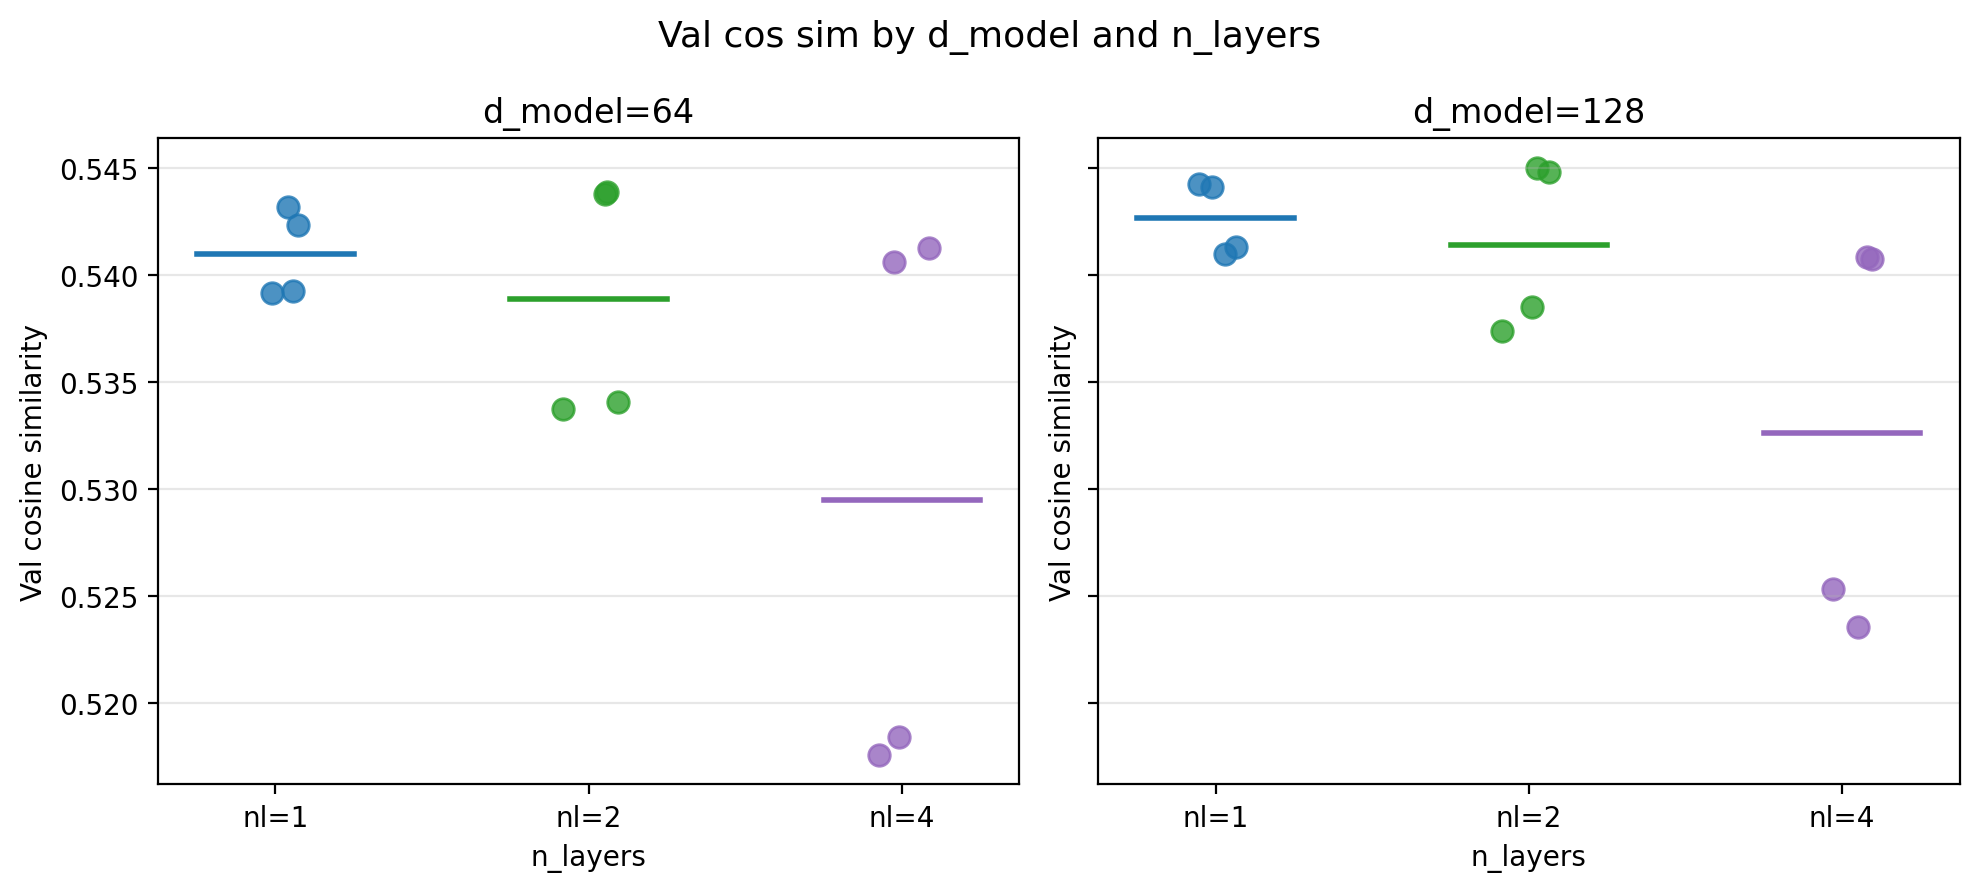

In [4]:
d_models = sorted(df['d_model'].dropna().unique())
n_layers = sorted(df['n_layers'].dropna().unique())
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, len(d_models), figsize=(5 * len(d_models), 4.5), sharey=True)
if len(d_models) == 1:
    axes = [axes]

palette = plt.cm.tab10(np.linspace(0, 0.4, len(n_layers)))

for ax, dm in zip(axes, d_models):
    sub = df[df['d_model'] == dm]
    for ci, nl in enumerate(n_layers):
        grp = sub[sub['n_layers'] == nl]['val_cos_sim'].dropna().values
        if not len(grp):
            continue
        jitter = rng.uniform(-0.1, 0.1, len(grp))
        ax.scatter(ci + jitter, grp, color=palette[ci], s=60, alpha=0.8, label=f'nl={int(nl)}')
        ax.plot([ci - 0.25, ci + 0.25], [grp.mean(), grp.mean()], color=palette[ci], linewidth=2)
    ax.set_title(f'd_model={int(dm)}')
    ax.set_xticks(range(len(n_layers)))
    ax.set_xticklabels([f'nl={int(nl)}' for nl in n_layers])
    ax.set_xlabel('n_layers')
    ax.set_ylabel('Val cosine similarity')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Val cos sim by d_model and n_layers', fontsize=13)
plt.tight_layout()
plt.show()

## LR and weight decay effect

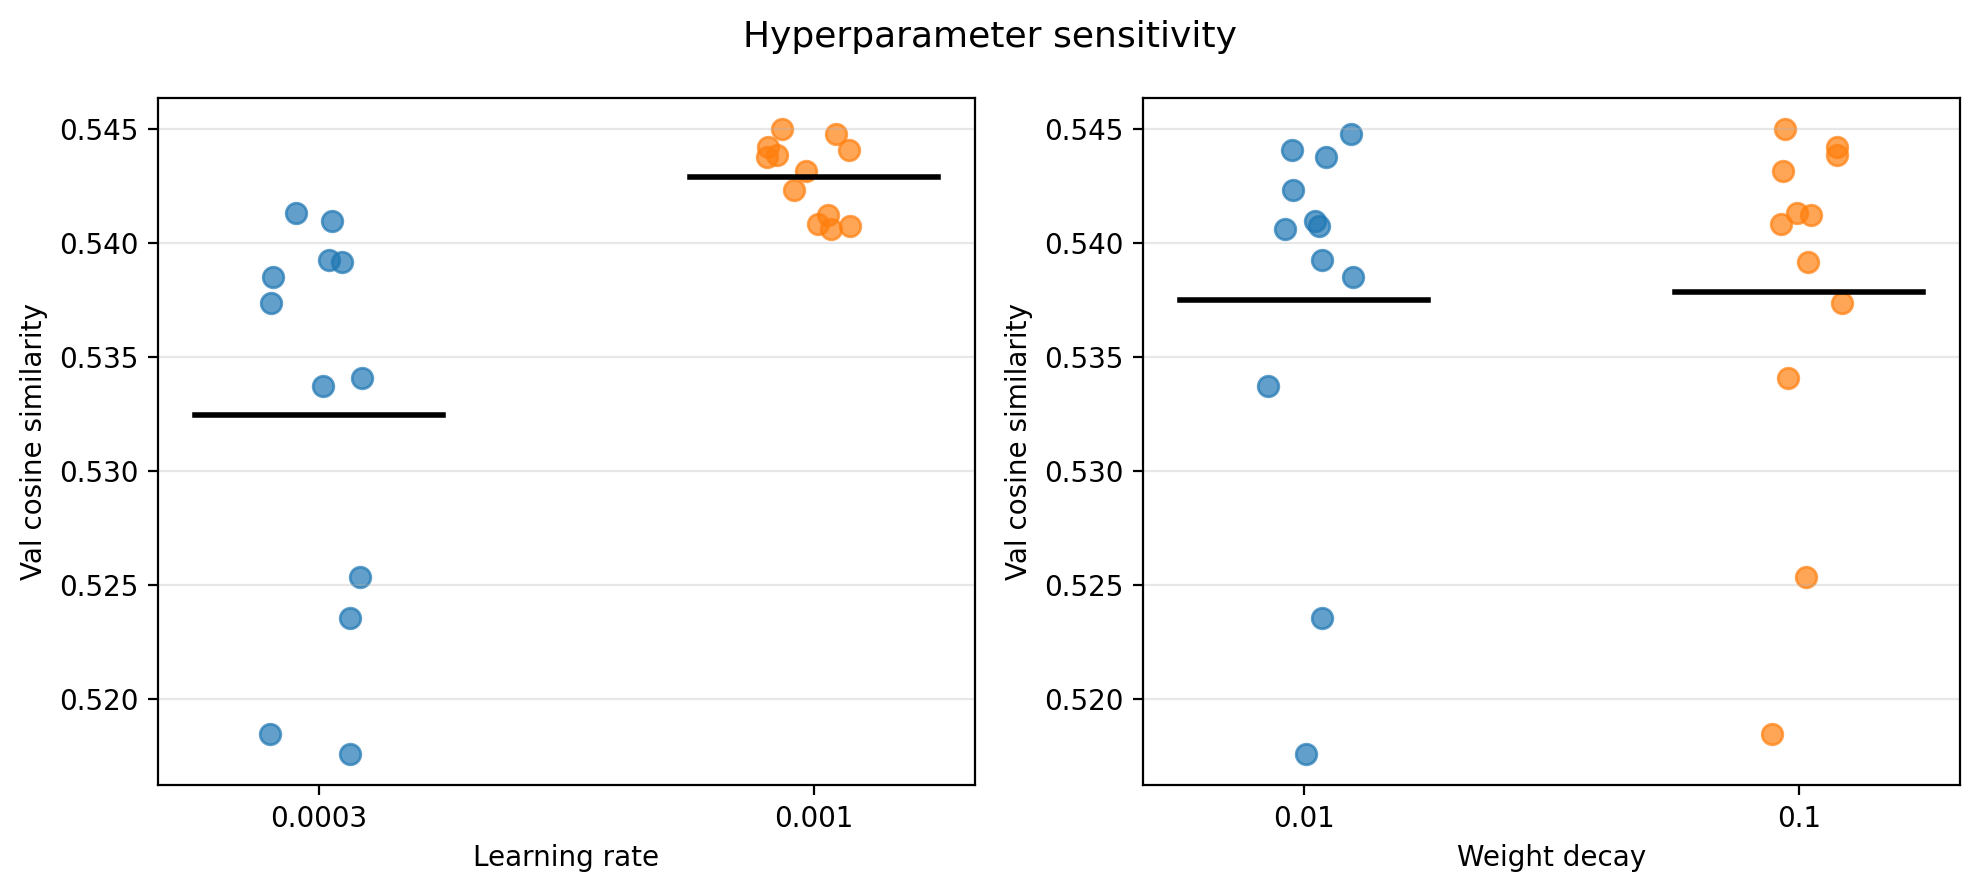

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
rng2 = np.random.default_rng(0)

for ax, col, label in [
    (axes[0], 'lr', 'Learning rate'),
    (axes[1], 'weight_decay', 'Weight decay'),
]:
    levels = sorted(df[col].dropna().unique())
    for i, lvl in enumerate(levels):
        grp = df[df[col] == lvl]['val_cos_sim'].dropna().values
        jitter = rng2.uniform(-0.1, 0.1, len(grp))
        ax.scatter(i + jitter, grp, alpha=0.7, s=55)
        ax.plot([i - 0.25, i + 0.25], [grp.mean(), grp.mean()], color='black', linewidth=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(label)
    ax.set_ylabel('Val cosine similarity')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Hyperparameter sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

## Train vs val MSE
Points below the diagonal (train < val) indicate healthy overfitting.

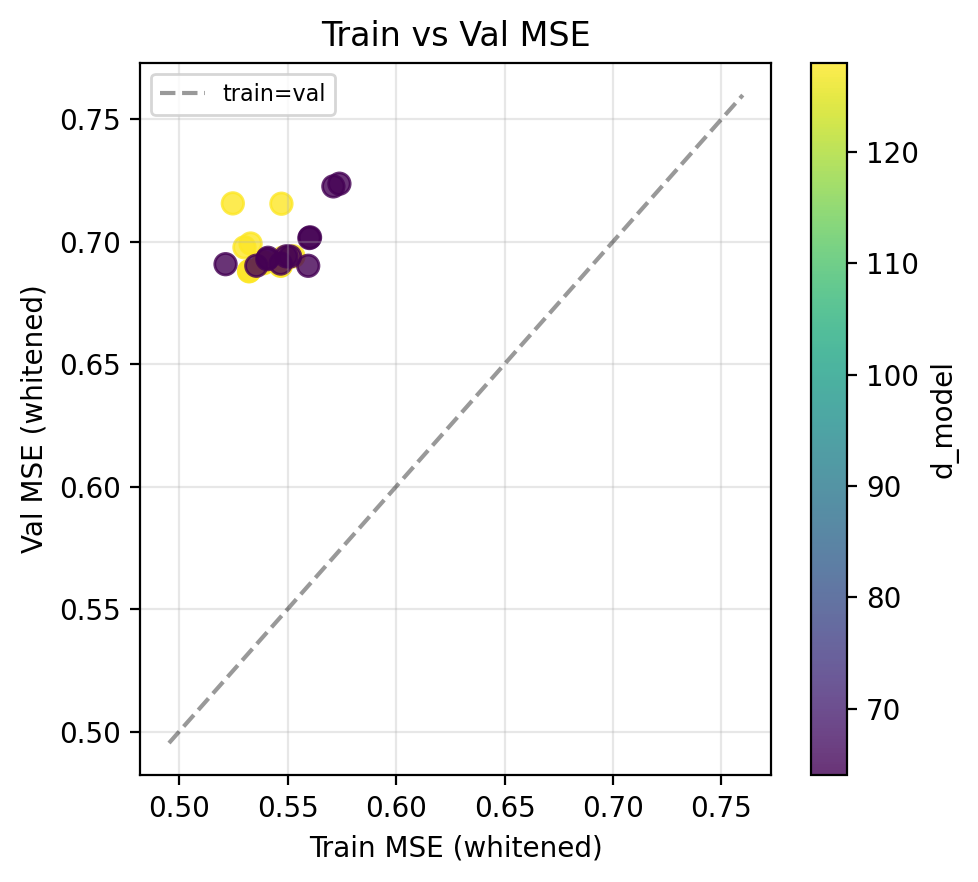

In [6]:
sub = df.dropna(subset=['train_mse', 'val_mse'])
fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(sub['train_mse'], sub['val_mse'], c=sub['d_model'], cmap='viridis', alpha=0.8, s=60)
lo = min(sub['train_mse'].min(), sub['val_mse'].min()) * 0.95
hi = max(sub['train_mse'].max(), sub['val_mse'].max()) * 1.05
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='train=val')
ax.set_xlabel('Train MSE (whitened)')
ax.set_ylabel('Val MSE (whitened)')
ax.set_title('Train vs Val MSE')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='d_model')
plt.tight_layout()
plt.show()

## Val vs Test generalisation

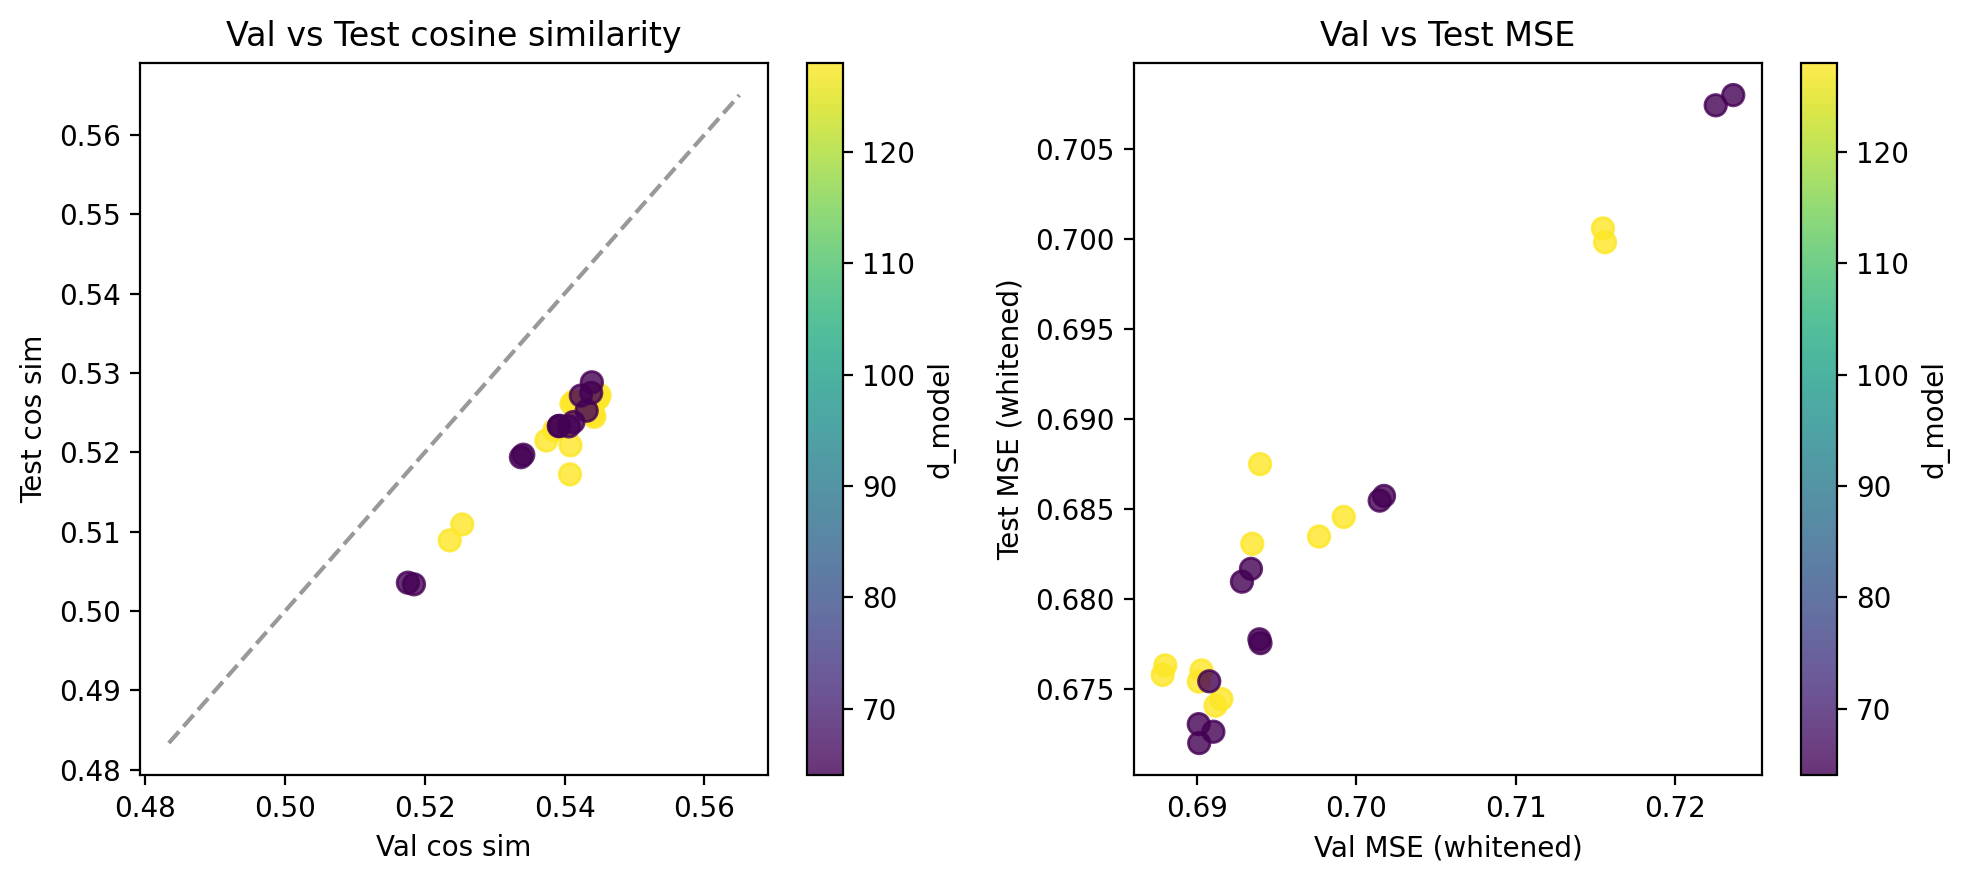

In [7]:
has_test = df['test_cos_sim'].notna().any()
if has_test:
    sub = df.dropna(subset=['val_cos_sim', 'test_cos_sim'])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    sc = axes[0].scatter(sub['val_cos_sim'], sub['test_cos_sim'],
                         c=sub['d_model'], cmap='viridis', alpha=0.8, s=60)
    lo = min(sub['val_cos_sim'].min(), sub['test_cos_sim'].min()) - 0.02
    hi = max(sub['val_cos_sim'].max(), sub['test_cos_sim'].max()) + 0.02
    axes[0].plot([lo, hi], [lo, hi], 'k--', alpha=0.4)
    axes[0].set_xlabel('Val cos sim')
    axes[0].set_ylabel('Test cos sim')
    axes[0].set_title('Val vs Test cosine similarity')
    plt.colorbar(sc, ax=axes[0], label='d_model')

    sc2 = axes[1].scatter(sub['val_mse'], sub['test_mse'],
                          c=sub['d_model'], cmap='viridis', alpha=0.8, s=60)
    axes[1].set_xlabel('Val MSE (whitened)')
    axes[1].set_ylabel('Test MSE (whitened)')
    axes[1].set_title('Val vs Test MSE')
    plt.colorbar(sc2, ax=axes[1], label='d_model')

    plt.tight_layout()
    plt.show()
else:
    print('No test metrics found.')

## Save best config

In [8]:
import json
from config_const import CACHE_DIR

best = df.sort_values('val_cos_sim', ascending=False).iloc[0]
cfg = {
    'dataset':          'hvm',
    'target':           'vae_latent_flat',
    'model':            'transformer',
    'use_category':     True,
    'normalize_output': False,
    'pool_hw':          int(best['pool_hw']),
    'val_cos_sim':      float(best['val_cos_sim']),
    'val_mse':          float(best['val_mse']),
    'test_cos_sim':     float(best['test_cos_sim']) if pd.notna(best['test_cos_sim']) else None,
    'test_mse':         float(best['test_mse']) if pd.notna(best['test_mse']) else None,
    'd_model':          int(best['d_model']),
    'n_heads':          4,
    'n_layers':         int(best['n_layers']),
    'lr':               float(best['lr']),
    'weight_decay':     float(best['weight_decay']),
    'checkpoint':       str(CKPT_ROOT / best['path'] / 'best.pt'),
}
out_path = CACHE_DIR / 'best_hvm_latent_config.json'
out_path.write_text(json.dumps(cfg, indent=2))
print(f'Saved to {out_path}')
print(json.dumps(cfg, indent=2))

Saved to /home/yy3658/NeurObjectGen/cache/best_hvm_latent_config.json
{
  "dataset": "hvm",
  "target": "vae_latent_flat",
  "model": "transformer",
  "use_category": true,
  "normalize_output": false,
  "pool_hw": 34,
  "val_cos_sim": 0.5450010299682617,
  "val_mse": 0.6878614127635956,
  "test_cos_sim": 0.5272006988525391,
  "test_mse": 0.6757656335830688,
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 2,
  "lr": 0.001,
  "weight_decay": 0.1,
  "checkpoint": "/home/yy3658/NeurObjectGen/checkpoints/hvm/transformer/vae_latent_flat/d128_nh4_nl2_hw34_do0.1_lr0.001_wd0.1_bs64_cat/best.pt"
}
